In [1]:
'''The objective is to understand customer purchasing behavior,
identify churn patterns,
analyze customer value,
and prepare data for predictive modeling.'''

'The objective is to understand customer purchasing behavior,\nidentify churn patterns,\nanalyze customer value,\nand prepare data for predictive modeling.'

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_parquet("../data/processed/customer_ml_features.parquet")

df.shape
df.head()
df.describe()

,customerkey,age,cohort_year,recency_days,customer_tenure_days,frequency,total_order_lines,total_quantity,unique_products_bought,unique_categories_bought,...,std_order_value,avg_items_per_order,avg_products_per_order,avg_categories_per_order,avg_days_between_orders,std_days_between_orders,purchase_velocity_orders_per_year,is_churned_180d,revenue_first_6m_after_first_purchase,future_6m_revenue
count,4.948700e+04,49487.00000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,...,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000,49487.000000
mean,1.106278e+06,51.84115,2019.664498,989.932952,520.387152,1.679835,4.038899,12.697678,4.029301,2.857215,...,987.233914,7.563287,2.401606,2.014441,5941.539185,85.194415,2.124086,0.860327,198.010552,168.924336
std,6.104534e+05,19.34160,2.501677,833.792272,789.397241,0.946187,2.977723,10.410423,2.964301,1.547214,...,2066.548941,5.038282,1.274098,0.913651,4566.752274,248.984714,14.781375,0.346651,1183.301980,1125.128949
min,1.500000e+01,19.00000,2015.000000,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.216810,0.000000,0.000000,0.000000
25%,5.449875e+05,35.00000,2018.000000,339.000000,0.000000,1.000000,2.000000,5.000000,2.000000,2.000000,...,0.000000,4.000000,1.500000,1.000000,795.416667,0.000000,0.983827,1.000000,0.000000,0.000000
50%,1.170564e+06,52.00000,2019.000000,680.000000,0.000000,1.000000,3.000000,10.000000,3.000000,3.000000,...,0.000000,6.750000,2.000000,2.000000,9999.000000,0.000000,1.000000,1.000000,0.000000,0.000000
75%,1.639910e+06,68.00000,2022.000000,1640.500000,939.000000,2.000000,5.000000,18.000000,5.000000,4.000000,...,1180.135356,10.000000,3.000000,2.500000,9999.000000,0.000000,1.000000,1.000000,0.000000,0.000000
max,2.099743e+06,85.00000,2024.000000,3397.000000,3367.000000,10.000000,31.000000,106.000000,30.000000,8.000000,...,48812.480700,43.000000,7.000000,7.000000,9999.000000,2230.214788,730.000000,1.000000,39049.623000,51333.592740


In [3]:
df["customer_status_180d"].value_counts()

customer_status_180d
Churned    42575
Active      6912
Name: count, dtype: int64

<Axes: xlabel='customer_status_180d'>

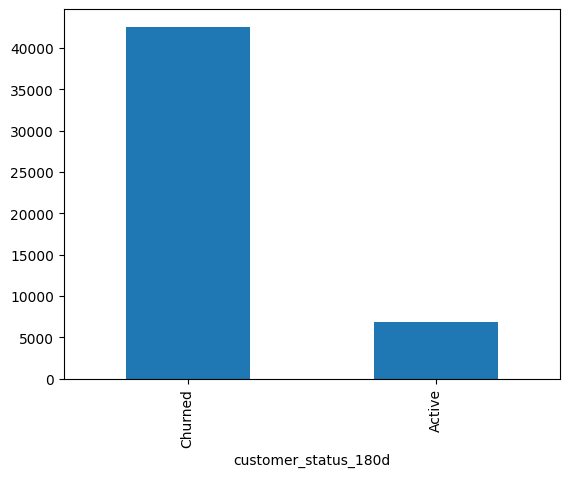

In [4]:
df["customer_status_180d"].value_counts().plot(
    kind="bar"
)

(array([1.000e+00, 1.000e+00, 1.600e+01, 4.800e+01, 4.600e+01, 6.300e+01,
        8.700e+01, 9.500e+01, 1.340e+02, 1.540e+02, 1.680e+02, 2.160e+02,
        2.270e+02, 2.640e+02, 2.980e+02, 3.140e+02, 3.330e+02, 4.120e+02,
        4.190e+02, 4.710e+02, 5.930e+02, 7.200e+02, 8.510e+02, 9.370e+02,
        1.094e+03, 1.286e+03, 1.457e+03, 1.706e+03, 1.912e+03, 2.159e+03,
        2.378e+03, 2.620e+03, 2.851e+03, 3.092e+03, 3.216e+03, 3.238e+03,
        3.034e+03, 2.913e+03, 2.613e+03, 2.248e+03, 1.673e+03, 1.181e+03,
        8.880e+02, 5.030e+02, 2.970e+02, 1.570e+02, 6.600e+01, 2.800e+01,
        7.000e+00, 2.000e+00]),
 array([ 0.92528746,  1.13308551,  1.34088355,  1.5486816 ,  1.75647964,
         1.96427769,  2.17207573,  2.37987378,  2.58767182,  2.79546987,
         3.00326791,  3.21106596,  3.418864  ,  3.62666205,  3.83446009,
         4.04225814,  4.25005619,  4.45785423,  4.66565228,  4.87345032,
         5.08124837,  5.28904641,  5.49684446,  5.7046425 ,  5.91244055,
         6.

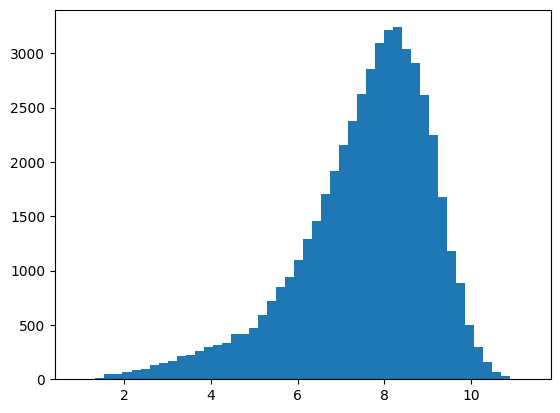

In [5]:
plt.hist(
    np.log1p(df["total_revenue"]),
    bins=50
)

In [6]:
segment = (
    df.groupby("historical_ltv_segment")
      ["total_revenue"]
      .sum()
)

In [7]:
(
    df.groupby("historical_ltv_segment")
      ["is_churned_180d"]
      .mean()
)

historical_ltv_segment
High-Value    0.826140
Low-Value     0.895894
Mid-Value     0.859637
Name: is_churned_180d, dtype: float64

In [8]:
cohort = (
    df.groupby("cohort_year")
      .agg(
          customers=("customerkey","count"),
          revenue=("total_revenue","sum")
      )
)

In [9]:
country = (
    df.groupby("countryfull")
      .agg(
          revenue=("total_revenue","sum"),
          churn=("is_churned_180d","mean")
      )
)

(array([  112.,   533.,  1173.,  1949.,  4195.,  8520., 14157., 14046.,
         4542.,   260.]),
 array([ 0.92528746,  1.96427769,  3.00326791,  4.04225814,  5.08124837,
         6.12023859,  7.15922882,  8.19821904,  9.23720927, 10.27619949,
        11.31518972]),
 <BarContainer object of 10 artists>)

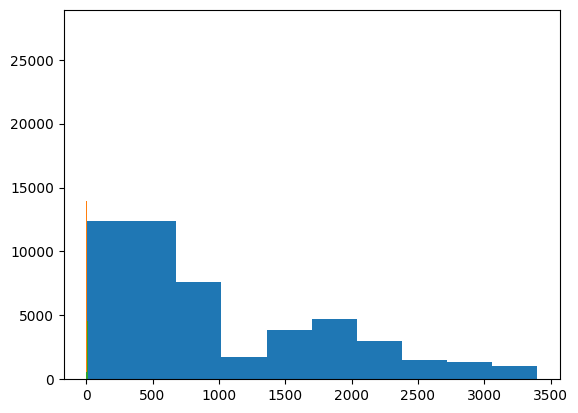

In [10]:
plt.hist(df["recency_days"])

plt.hist(df["frequency"])

plt.hist(
    np.log1p(df["monetary_value"])
)

In [11]:
corr = (
    df.select_dtypes(include="number")
      .corr()
)

In [12]:
df.groupby("customer_status_180d")[
    [
        "recency_days",
        "frequency",
        "monetary_value"
    ]
].mean()

,recency_days,frequency,monetary_value
customer_status_180d,,,
Active,96.829138,2.154803,4901.467073
Churned,1134.927281,1.602725,4052.345230
